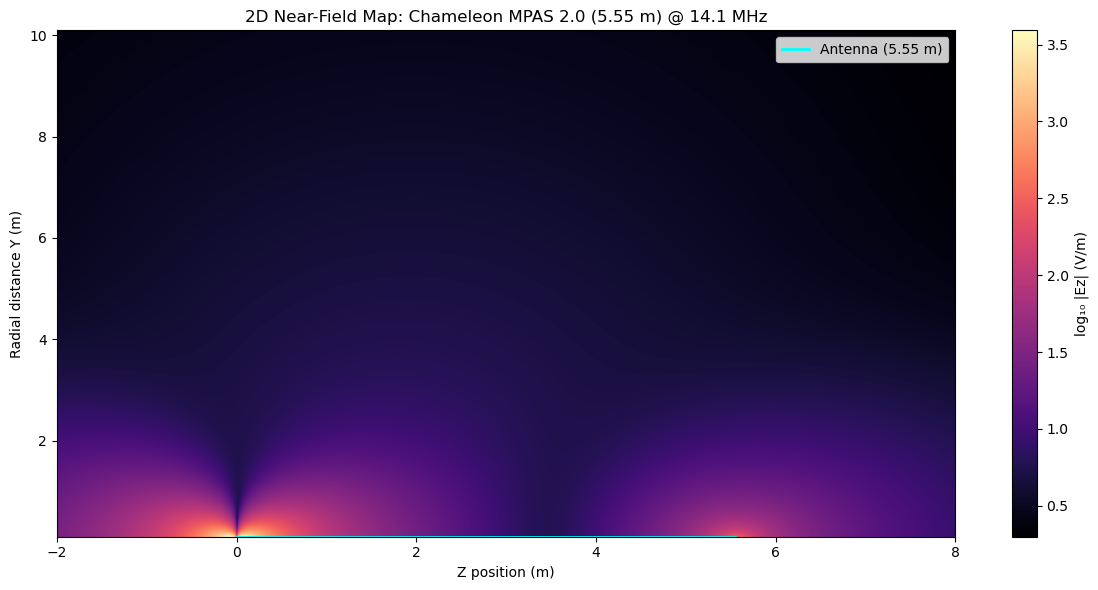

Saved field_map.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt

grid_size = 1000
data = np.fromfile('./cmake-build-debug/field_map.bin', dtype=np.float64).reshape((grid_size, grid_size))

# Bounds must match C++ code: z [-2, 8], y [0.1, 10.1]
extent = [-2.0, 8.0, 0.1, 10.1]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(np.log10(data), extent=extent, origin='lower', cmap='magma', aspect='auto')
fig.colorbar(im, ax=ax, label='log₁₀ |Ez| (V/m)')

ax.set_title('2D Near-Field Map: Chameleon MPAS 2.0 (5.55 m) @ 14.1 MHz')
ax.set_xlabel('Z position (m)')
ax.set_ylabel('Radial distance Y (m)')

# Antenna wire: base at z=0, tip at z=5.55, just above y_min
ax.plot([0, 5.55], [0.1, 0.1], color='cyan', lw=2, label='Antenna (5.55 m)')
ax.legend()

plt.tight_layout()
plt.savefig('field_map.png', dpi=150)
plt.show()
print("Saved field_map.png")

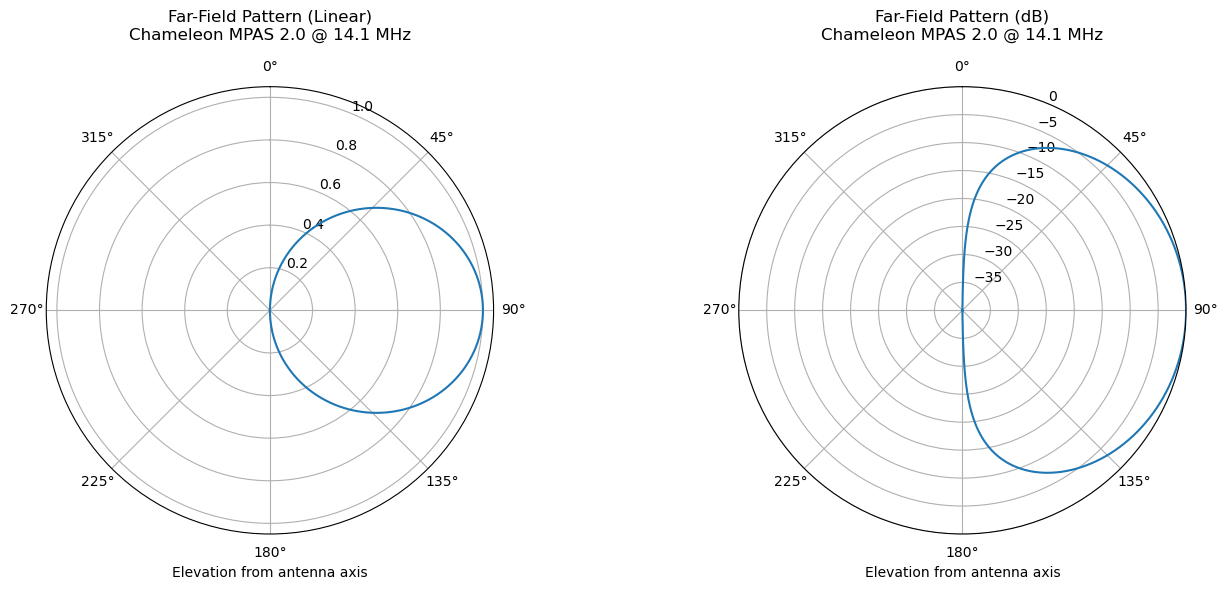

Saved far_field.png


In [2]:

# Far-Field Radiation Pattern
# Matches C++ current distribution: I(z) = sin(K * (L - z))

f      = 14.1e6
c      = 299792458.0
lam    = c / f
k      = 2 * np.pi / lam
L      = 5.55
N_seg  = 500
dz     = L / N_seg

z_n = (np.arange(N_seg) + 0.5) * dz
I_n = np.sin(k * (L - z_n))  # sinusoidal current distribution

theta = np.linspace(0, np.pi, 1800)  # elevation angle from z-axis

# Array factor: sum over segments with phase e^(jk z_n cos(theta))
AF = np.sum(I_n[:, None] * dz * np.exp(1j * k * z_n[:, None] * np.cos(theta[None, :])), axis=0)

E_theta = np.abs(np.sin(theta) * AF)
E_norm  = E_theta / E_theta.max()
E_dB    = 20 * np.log10(np.clip(E_norm, 1e-6, None))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': 'polar'})

for ax, (data, label, vmin) in zip(axes, [
    (E_norm,  'Linear',  None),
    (E_dB,    'dB',      -40),
]):
    ax.plot(theta, np.clip(data, vmin, None) if vmin else data, lw=1.5)
    if vmin:
        ax.set_rmin(vmin)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title(f'Far-Field Pattern ({label})\nChameleon MPAS 2.0 @ 14.1 MHz', pad=15)
    ax.set_xlabel('Elevation from antenna axis')

plt.tight_layout()
plt.savefig('far_field.png', dpi=150)
plt.show()
print("Saved far_field.png")


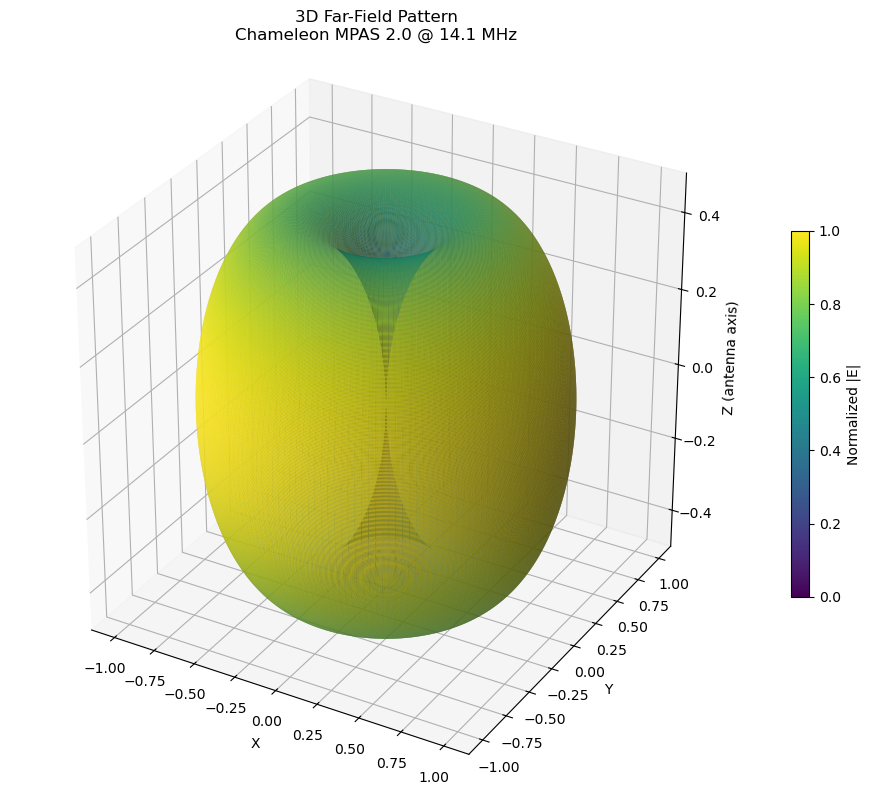

Saved far_field_3d.png


In [3]:

# 3D Far-Field Radiation Pattern (surface of revolution around z-axis)
phi = np.linspace(0, 2 * np.pi, 360)
THETA, PHI = np.meshgrid(theta, phi)

R = np.tile(E_norm, (len(phi), 1))

X = R * np.sin(THETA) * np.cos(PHI)
Y = R * np.sin(THETA) * np.sin(PHI)
Z = R * np.cos(THETA)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(R / R.max()),
                       rstride=2, cstride=2, alpha=0.9, linewidth=0)

ax.set_title('3D Far-Field Pattern\nChameleon MPAS 2.0 @ 14.1 MHz')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z (antenna axis)')
ax.set_box_aspect([1, 1, 1])

m = plt.cm.ScalarMappable(cmap=plt.cm.viridis)
m.set_array(E_norm)
fig.colorbar(m, ax=ax, shrink=0.5, label='Normalized |E|')

plt.tight_layout()
plt.savefig('far_field_3d.png', dpi=150)
plt.show()
print("Saved far_field_3d.png")
